# Team Rocket

<div style="width:100%; margin: auto;">

[![no internet?](https://www.pokemon.com/static-assets/content-assets/cms2/img/watch-pokemon-tv/seasons/season16/season16_ep42_ss04.jpg)](link_url)

# Step 1 Import

One row of data is one race of typeracer, and contains the 'Universe',
 'Race #',
 'Mode',
 'Race ID',
 'Text ID',
 'Skill Level',
 'WPM',
 'Accuracy',
 'Points',
 'Rank',
 '# Racers',
 'Keylog',
 'Date/Time (UTC)'.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from datetime import date
from datetime import timedelta

# Read in csv
data = pd.read_csv('typeracer.csv')

# Set theme for figures
sns.set_theme(style='whitegrid')



# Questions?

1. What is the relationship between WPM and time?

2. What is the relationship between WPM and accuracy by rank?
 
3. Do Jacob's WPMs increase or decrease over the course of a typeracing session?

# Step 2 Explore

Below we look at what rows contain nulls, the shape of the data, which type each column is, and other info.

We found that there is one column 'Mode' that contains 26 nulls, and every other value just says unknown. Also, there's a column that logs keystrokes 'Keylog'.

In [ ]:
# Explore df shape
print(data.shape)
# Checking for null values in all columns
data.isnull().sum()
# Display df descriptive satistics - WPM and Accuracy columns
data.describe()
# Exploring Mode columns
data['Mode'].unique()

array([nan, 'unknown'], dtype=object)

 Why did we set the fatigue and WPM over time question aside?

The easiest question was WPM/Accuracy by Rank because it only required one line of code. We are saving the fun stuff for later. The time question involves times which are scary. The fatigue question requires many steps, so that's more work.

# Step 3 Clean

We didn't have any missing data or wonky data in our columns of interest.

# Step 4 Filter

We filtered out columns we don't like. For WPM over time we filtered data past 2024 because there were only 27 races prior to 2025 and it skewed the plot.

In [ ]:
# Removing columns we are not using
colwedontlike = ['Universe','Mode','Race ID','Text ID','Skill Level','Points','Keylog']
filtereddata = data.drop(columns=colwedontlike)
filtereddata

,Race #,WPM,Accuracy,Rank,# Racers,Date/Time (UTC)
0,1,78.792671,0.984772,1,2,2020-03-19 08:01:48.376000
1,2,78.204735,0.990909,1,2,2020-03-19 08:03:19.026000
2,3,67.742561,0.964286,2,2,2020-03-19 08:04:53.415000
3,4,63.499229,0.959677,2,2,2020-03-19 08:07:04.356000
4,5,71.666359,0.972103,1,2,2020-03-19 08:09:08.319000
...,...,...,...,...,...,...
994,995,82.306892,0.965368,3,4,2025-04-05 02:26:04.897000
995,996,82.082901,0.966463,2,4,2025-04-05 02:27:00.026000
996,997,100.449821,0.986532,3,5,2025-04-05 02:27:46.990000
997,998,81.719856,0.961066,2,5,2025-04-05 02:29:28.121000


# Step 5 Sort

We will sort the data first by rank (ascending order), and then by WPM (descending order) to see my highest WPMs when I won.

In [4]:
filtereddata.sort_values(by = ['Rank','WPM'], ascending=[True, False])

,Race #,WPM,Accuracy,Rank,# Racers,Date/Time (UTC)
921,922,116.453461,1.000000,1,5,2025-03-20 23:57:35.448000
897,898,111.957581,0.996454,1,5,2025-03-12 18:06:33.307000
958,959,109.874771,0.978723,1,2,2025-03-28 00:01:22.633000
886,887,108.607315,0.995984,1,5,2025-03-11 18:36:22.630000
135,136,107.683678,0.994845,1,5,2024-12-13 18:34:05.806000
...,...,...,...,...,...,...
825,826,66.009193,0.944444,5,5,2025-03-10 04:57:55.735000
218,219,60.671116,0.929078,5,5,2024-12-22 08:13:35.912000
221,222,59.067219,0.940984,5,5,2024-12-22 08:17:25.216000
37,38,55.077625,0.972603,5,5,2024-11-08 19:48:14.487000


# Step 6 Transform

Our datetime column 'Date/Time (UTC)' was in string format and needed to be coherced into datetime format, and then needed to be coerced again into a numeric format for regression lines to answer questions 1 and 2. Then we filtered out rows that were before 2025 for calculations used in WPM over time.

In [5]:
filtereddata['Timestamp'] = pd.to_datetime(filtereddata['Date/Time (UTC)'], format='%Y-%m-%d %H:%M:%S.%f')
filtereddata['JustDate'] = filtereddata['Timestamp'].dt.date
filtereddata['Date'] = mdates.date2num(filtereddata['JustDate'])
typing2025 = filtereddata[filtereddata['Timestamp'].dt.year >= 2024]
typing2025

,Race #,WPM,Accuracy,Rank,# Racers,Date/Time (UTC),Timestamp,JustDate,Date
29,30,75.304680,0.962963,1,2,2024-10-04 17:03:52.125000,2024-10-04 17:03:52.125,2024-10-04,20000.0
30,31,73.083733,0.968421,3,5,2024-10-04 18:56:56.820000,2024-10-04 18:56:56.820,2024-10-04,20000.0
31,32,81.917763,0.973684,1,2,2024-10-05 20:53:59.744000,2024-10-05 20:53:59.744,2024-10-05,20001.0
32,33,91.332970,0.995575,1,2,2024-10-05 20:55:33.171000,2024-10-05 20:55:33.171,2024-10-05,20001.0
33,34,89.473328,0.975104,1,2,2024-10-05 20:57:14.010000,2024-10-05 20:57:14.010,2024-10-05,20001.0
...,...,...,...,...,...,...,...,...,...
994,995,82.306892,0.965368,3,4,2025-04-05 02:26:04.897000,2025-04-05 02:26:04.897,2025-04-05,20183.0
995,996,82.082901,0.966463,2,4,2025-04-05 02:27:00.026000,2025-04-05 02:27:00.026,2025-04-05,20183.0
996,997,100.449821,0.986532,3,5,2025-04-05 02:27:46.990000,2025-04-05 02:27:46.990,2025-04-05,20183.0
997,998,81.719856,0.961066,2,5,2025-04-05 02:29:28.121000,2025-04-05 02:29:28.121,2025-04-05,20183.0


# Step 7 and 8 Group and Aggregate

We need to create a column that designates a session ID, which we will group by when doing the analysis. And then we have to create an attempt number column for each session ID.

A session is defined as a group of races where each race occurs within 10 minuts of the next.



In [6]:
#creating new dataset where sessionids will be created
fatiguedata = filtereddata.copy()
fatiguedata['sessionid'] = pd.Series(dtype='Int64')


fatiguedata.loc[0,'sessionid'] = 1

#loop that creates session ids (each session is defined as a group of races where each race occurs within 10 minuts of the next)
for x in range(1,len(fatiguedata)):
    if ((fatiguedata.loc[x,'Timestamp'] - fatiguedata.loc[(x-1),'Timestamp']).seconds) > 600:
        fatiguedata.loc[x,'sessionid'] = (fatiguedata.loc[(x-1),'sessionid'] + 1)
    else:
        fatiguedata.loc[x,'sessionid'] = fatiguedata.loc[(x-1),'sessionid']



In [7]:
#filtering sessions that have 10 or more attempts

sessionidwherecountistrue = (fatiguedata['sessionid'].value_counts() >10).reset_index()
sessionidwherecountistrue = sessionidwherecountistrue[sessionidwherecountistrue['count']==True]


#Step 9 Join or Reshape

We merge our df that tells us which sessions have more than 10 attempts in it with the df that contains data for each session. Then we create a column that denotes each attempt per session.

In [8]:
#merge the list of sessions with more than 10 attempts with the session data
sessionid10 = pd.merge(sessionidwherecountistrue, fatiguedata, on='sessionid',how ='left')

#create an empty row of type integer, and first row in that column assigned value 1
sessionid10['Attempt Number'] = pd.Series(dtype='Int64')
sessionid10.loc[0,'Attempt Number'] = 1

#loop to assign attempt number for each session
for x in range(1,len(sessionid10)):
    if sessionid10.loc[x,'sessionid'] == sessionid10.loc[(x-1),'sessionid']:
        sessionid10.loc[x,'Attempt Number'] = (sessionid10.loc[(x-1),'Attempt Number']) +1
    else:
        sessionid10.loc[x,'Attempt Number'] = 1


#coerce sessionid column to string from int so hue= works on it
sessionid10['sessionid'] = sessionid10['sessionid'].astype(str)

# Step 10 Figures

### What is the relationship between WPM and time?

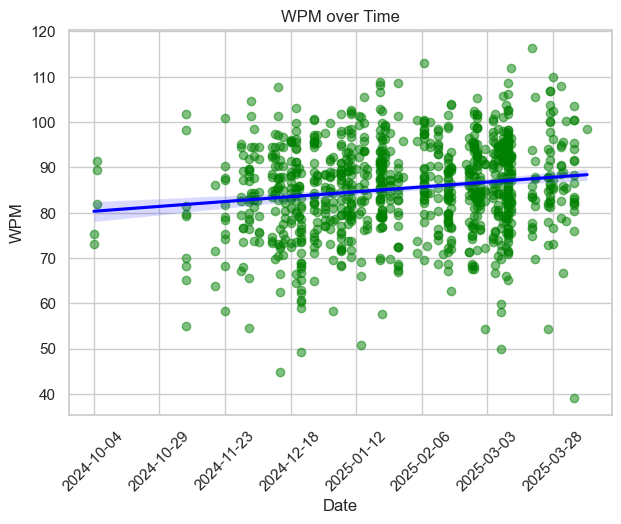

In [9]:
plt.figure(figsize=(7,5))
scatterplt = sns.regplot(x='Date', y = 'WPM', data = typing2025, line_kws={'color':'blue'}, scatter_kws={'color':'green', 'alpha':0.5})
scatterplt.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation = 45)
plt.title('WPM over Time')


plt.show()

Figure 1: Each point represents one typerace and depicts the words per minute (WPM) of that typerace plotted over time (October 2024 - March 2025)

### What is the relationship between WPM and accuracy by rank?

<Axes: xlabel='WPM', ylabel='Accuracy'>

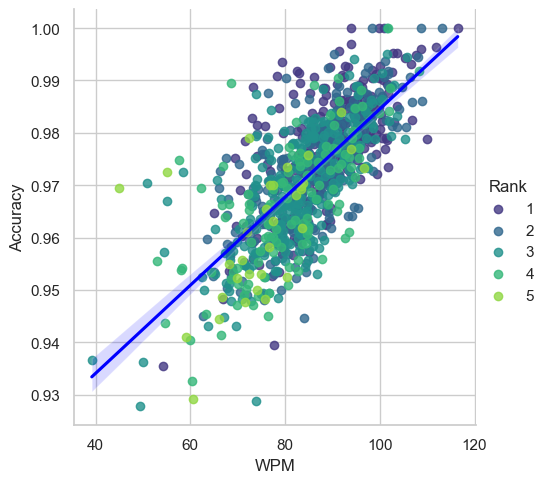

In [10]:
g = sns.lmplot(
    data = filtereddata,
    x = 'WPM',
    y= 'Accuracy',
    hue= 'Rank',
    fit_reg= False,
    palette='viridis'
)

sns.regplot(
    data = filtereddata,
    x = 'WPM',
    y = 'Accuracy',
    scatter = False,
    ax=g.ax,
    color='blue'
)

Figure 2: Each point represents one typerace plotted by words per minute (WPM) and accuracy, then colored by rank (placement) in the typerace. The regression shows a positive correlation between WPM and acuracy over all typeraces.

### Do Jacob's WPMs increase or decrease over the course of a typeracing session?

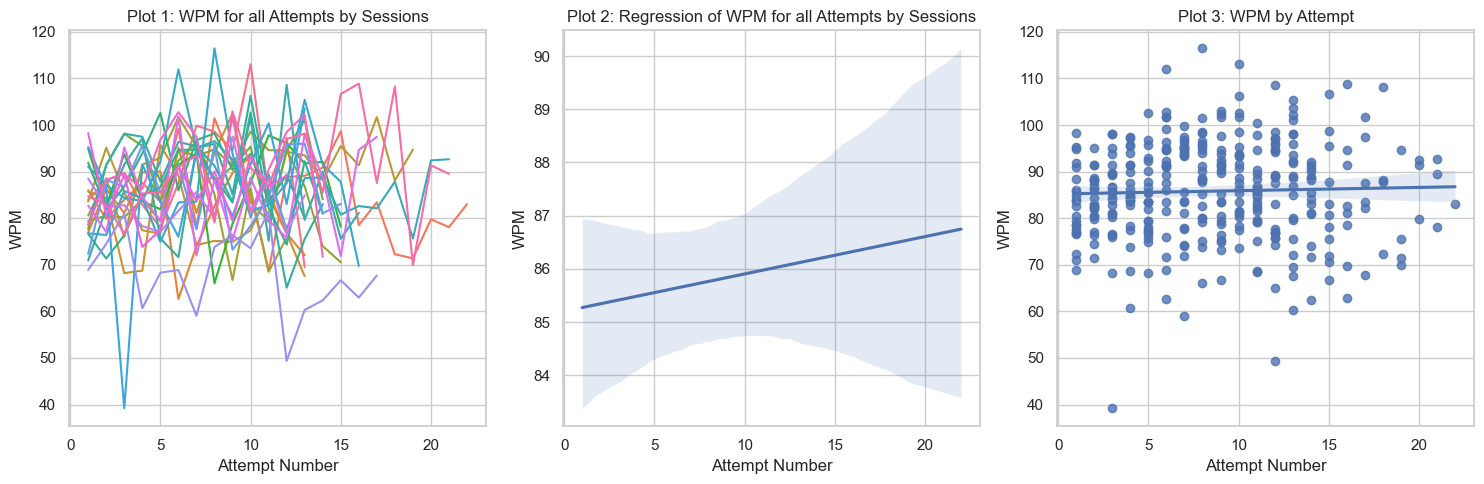

In [11]:
from sqlalchemy import false

# initializing a PLot Grid
fig, axes = plt.subplots(1, 3, figsize = (15, 5))

#Plot 1
sns.lineplot(x='Attempt Number', y='WPM',hue='sessionid', data=sessionid10.sort_values('sessionid'), ax=axes[0],legend= False)
axes[0].set_title('Plot 1: WPM for all Attempts by Sessions')

# Plot 2
sns.regplot(
    data = sessionid10,
    x = 'Attempt Number',
    y = 'WPM',
    scatter = False,
    ax=axes[1]
)
axes[1].set_title('Plot 2: Regression of WPM for all Attempts by Sessions')
# Plot 3
sns.regplot(
    data = sessionid10,
    x = 'Attempt Number',
    y = 'WPM',
    scatter = True,
    ax=axes[2]
)
axes[2].set_title('Plot 3: WPM by Attempt')

plt.tight_layout()
plt.show()

Figure 3: Each plot describes the relationship between attempts in a session and WPM. Plot 1 is WPM in each attempt plotted as a line for each session. Plot 2 is the linear regression line for the data in plot 1. Plot 3 is the distribution of each individual race's WPM with the same linear regression line.